# Kaggle Setup

In [ ]:
# Please change these two variables in the bottom of the file `../.env `  to your Kaggle username and key, which you can find in your Kaggle account settings. 
# This will allow you to download the dataset directly from Kaggle using the Kaggle API.

# KAGGLE_USERNAME = 'your_kaggle_username'
# KAGGLE_KEY = 'your_kaggle_key'



# Raw Data Setup

In [3]:
%run ../assignment3/dataset.py

e:\poetry_cache\virtualenvs\assignment3-HMuFVmZG-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-24 13:28:41.037 | INFO     | __main__:setup_dirs:57 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\raw
2026-04-24 13:28:41.040 | INFO     | __main__:setup_dirs:57 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\interim
2026-04-24 13:28:41.041 | INFO     | __main__:setup_dirs:57 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\processed
2026-04-24 13:28:41.041 | INFO     | __main__:setup_dirs:57 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\external
2026-04-24 13:28:41.042 | INFO     | __main__:setup_dirs:57 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\reports\figures
2026-04-24 13:28:41.042 | INFO     | __main__:download_counsel_chat:88 - Downloading Counsel Chat dataset from Hugging Face...


Repo card metadata block was not found. Setting CardData to empty.


2026-04-24 13:28:44.822 | SUCCESS  | __main__:download_counsel_chat:91 - Counsel Chat saved to D:\MS_DSI\AI\Assignment3\assignment3\data\raw\counsel_chat_raw.csv (2,775 rows)
2026-04-24 13:28:44.825 | INFO     | __main__:_load_kaggle_credentials:82 - Loaded Kaggle credentials for user: doombuoy
2026-04-24 13:28:45.377 | INFO     | __main__:download_crisis_data:121 - Downloading nikhileswarkomati/suicide-watch from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch


100%|██████████| 60.6M/60.6M [00:28<00:00, 2.21MB/s]



2026-04-24 13:29:17.644 | SUCCESS  | __main__:download_crisis_data:152 - Crisis data saved to D:\MS_DSI\AI\Assignment3\assignment3\data\raw\crisis_raw.csv (1,025,102 rows)
2026-04-24 13:29:17.645 | SUCCESS  | __main__:main:159 - All raw datasets downloaded.


## Cell 1 - Imports and setup

In [4]:
import re
import html
import unicodedata
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
import sys


# config.py lives at ../assignment3/config.py relative to this file.
# __file__ exists in .py scripts but not in Jupyter notebooks, so fall back to cwd.
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent / "assignment3"))
 
from config import RAW_DATA_DIR, INTERIM_DATA_DIR, FIGURES_DIR

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Raw data dir:     {RAW_DATA_DIR}")
print(f"Interim data dir: {INTERIM_DATA_DIR}")
print(f"Figures dir:      {FIGURES_DIR}")

Raw data dir:     D:\MS_DSI\AI\Assignment3\assignment3\data\raw
Interim data dir: D:\MS_DSI\AI\Assignment3\assignment3\data\interim
Figures dir:      D:\MS_DSI\AI\Assignment3\assignment3\reports\figures


# PART 1 - COUNSEL CHAT (RAG knowledge base)

## Cell 2 - Load and peek

In [5]:
counsel_raw = pd.read_csv(RAW_DATA_DIR / "counsel_chat_raw.csv")

print(f"Shape: {counsel_raw.shape}")
print(f"\nColumns: {counsel_raw.columns.tolist()}")
print(f"\nDtypes:\n{counsel_raw.dtypes}")
counsel_raw.head(3)

Shape: (2775, 10)

Columns: ['questionID', 'questionTitle', 'questionText', 'questionLink', 'topic', 'therapistInfo', 'therapistURL', 'answerText', 'upvotes', 'views']

Dtypes:
questionID       int64
questionTitle      str
questionText       str
questionLink       str
topic              str
therapistInfo      str
therapistURL       str
answerText         str
upvotes          int64
views            int64
dtype: object


,questionID,questionTitle,questionText,questionLink,topic,therapistInfo,therapistURL,answerText,upvotes,views
0,0,Do I have too many issues for counseling?,"I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anx...",https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling,depression,Jennifer MolinariHypnotherapist & Licensed Counselor,https://counselchat.com/therapists/jennifer-molinari,"It is very common for people to have multiple issues that they want to (and need to) address in counseling. I have had clients ask that same question and through more exploration, there is often ...",3,1971
1,0,Do I have too many issues for counseling?,"I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anx...",https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling,depression,"Jason Lynch, MS, LMHC, LCAC, ADSIndividual & Couples Therapy",https://counselchat.com/therapists/jason-lynch-ms-lmhc-lcac-ads,"I've never heard of someone having ""too many issues"" for therapy to be effective. A competent therapist will assist you in identifying the root causes of your problems and treat those first. If th...",2,386
2,0,Do I have too many issues for counseling?,"I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anx...",https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling,depression,Shakeeta TorresFaith Based Mental Health Counselor,https://counselchat.com/therapists/shakeeta-torres,Absolutely not. I strongly recommending working on one issue/need at a time. In therapy you will set smart goals and objectives that will help you reach your goals. I see you as a survivor and ...,2,3071


## Cell 3 - Random sample (more honest than .head())

In [6]:
for i, row in counsel_raw.sample(5, random_state=RANDOM_STATE).iterrows():
    print(f"--- Row {i} ---")
    for col in counsel_raw.columns:
        val = row[col]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "..."
        print(f"{col}: {val}")
    print()

--- Row 879 ---
questionID: 250
questionTitle: How should I handle the child I had with my ex-wife?
questionText: My ex-wife married and used me to have a child. She now uses that child as a pawn. I know my child misses me, but I need to move on and not live in the past. How do I do this? Do I see my child as much as possible or very little? Is it more confusing for the child?
questionLink: https://counselchat.com/questions/how-should-i-handle-the-child-i-had-with-my-ex-wife
topic: parenting
therapistInfo: Sherry Katz, LCSWCouples and Family Therapist, LCSW
therapistURL: https://counselchat.com/therapists/sherry-katz-lcsw
answerText: What are the ways your ex-wife uses your child as a pawn?This answer determines the best ways to handle particular situations.Basically, distinguish that your father relationship to your child lasts has great meaning for your child and as the adult, the responsibility for managing this relationship ...
upvotes: 0
views: 77

--- Row 1989 ---
questionID: 699

## Cell 4 - Missing values and duplicates

In [7]:
print("Missing values per column:")
print(counsel_raw.isna().sum())
print(f"\nTotal rows: {len(counsel_raw):,}")
print(f"Exact duplicate rows: {counsel_raw.duplicated().sum():,}")

content_cols = [
    c for c in counsel_raw.columns
    if c.lower() in {"questiontext", "answertext", "questiontitle", "question", "answer"}
]
print(f"\nContent columns detected: {content_cols}")
if content_cols:
    print(f"Duplicates on content columns: {counsel_raw.duplicated(subset=content_cols).sum():,}")

Missing values per column:
questionID         0
questionTitle      0
questionText     139
questionLink       0
topic              0
therapistInfo      0
therapistURL       0
answerText        26
upvotes            0
views              0
dtype: int64

Total rows: 2,775
Exact duplicate rows: 0

Content columns detected: ['questionTitle', 'questionText', 'answerText']
Duplicates on content columns: 2


## Cell 5 - Topic distribution

Unique topics: 31
topic
depression                  465
anxiety                     358
counseling-fundamentals     270
intimacy                    248
relationships               202
parenting                   191
family-conflict             144
trauma                      102
self-esteem                 100
relationship-dissolution     98
behavioral-change            69
lgbtq                        65
marriage                     52
anger-management             48
spirituality                 47
substance-abuse              45
professional-ethics          41
grief-and-loss               37
workplace-relationships      36
social-relationships         25
Name: count, dtype: int64


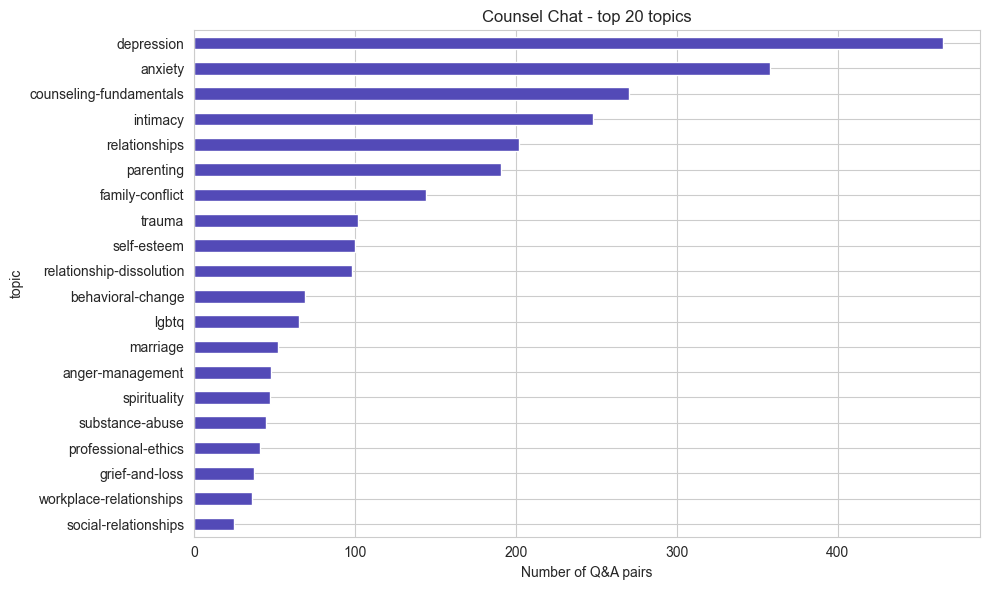

In [8]:
if "topic" in counsel_raw.columns:
    topic_counts = counsel_raw["topic"].value_counts()
    print(f"Unique topics: {len(topic_counts)}")
    print(topic_counts.head(20))

    fig, ax = plt.subplots(figsize=(10, 6))
    topic_counts.head(20).plot(kind="barh", ax=ax, color="#534AB7")
    ax.invert_yaxis()
    ax.set_xlabel("Number of Q&A pairs")
    ax.set_title("Counsel Chat - top 20 topics")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "counsel_topic_distribution.png", dpi=120)
    plt.show()
else:
    print("No 'topic' column - skipping.")

## Cell 6 - Text length distributions

Question col: questionText | Answer col: answerText

Question length stats (words):
count    2775.0
mean       49.2
std        43.2
min         0.0
25%        24.0
50%        41.0
75%        63.0
max       526.0
Name: q_words, dtype: float64

Answer length stats (words):
count    2775.0
mean      166.4
std       119.0
min         0.0
25%        86.0
50%       134.0
75%       212.0
max       939.0
Name: a_words, dtype: float64


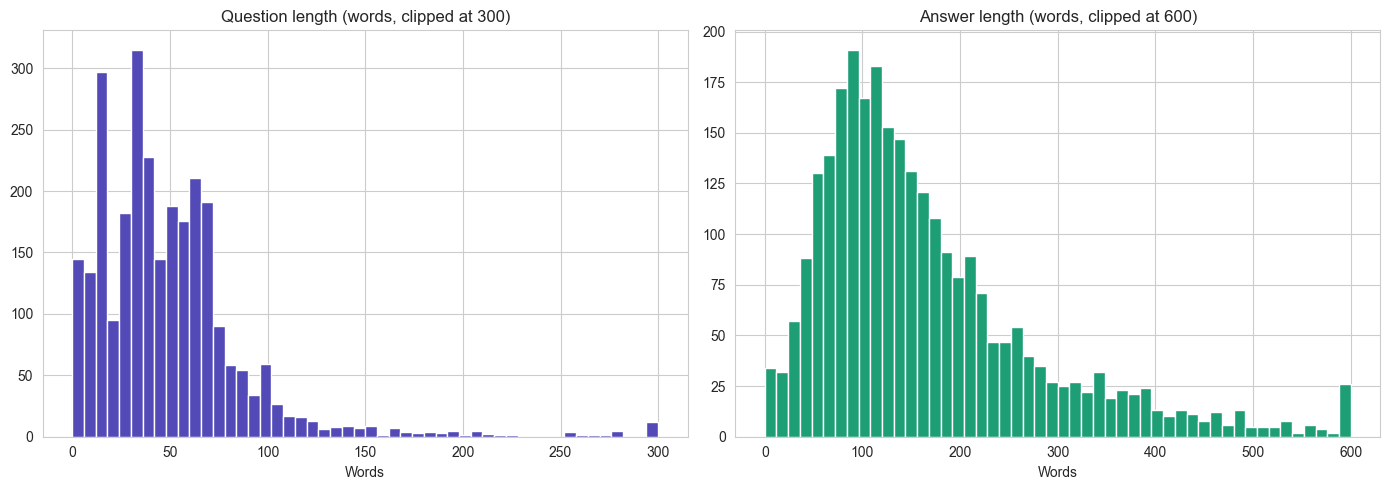

In [9]:
q_col = next((c for c in ["questionText", "question", "questionTitle"] if c in counsel_raw.columns), None)
a_col = next((c for c in ["answerText", "answer"] if c in counsel_raw.columns), None)
print(f"Question col: {q_col} | Answer col: {a_col}")


def char_len(series):
    return series.fillna("").astype(str).str.len()


def word_len(series):
    return series.fillna("").astype(str).str.split().str.len()


if q_col and a_col:
    counsel_raw["q_chars"] = char_len(counsel_raw[q_col])
    counsel_raw["a_chars"] = char_len(counsel_raw[a_col])
    counsel_raw["q_words"] = word_len(counsel_raw[q_col])
    counsel_raw["a_words"] = word_len(counsel_raw[a_col])

    print("\nQuestion length stats (words):")
    print(counsel_raw["q_words"].describe().round(1))
    print("\nAnswer length stats (words):")
    print(counsel_raw["a_words"].describe().round(1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(counsel_raw["q_words"].clip(upper=300), bins=50, color="#534AB7", edgecolor="white")
    axes[0].set_title("Question length (words, clipped at 300)")
    axes[0].set_xlabel("Words")
    axes[1].hist(counsel_raw["a_words"].clip(upper=600), bins=50, color="#1D9E75", edgecolor="white")
    axes[1].set_title("Answer length (words, clipped at 600)")
    axes[1].set_xlabel("Words")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "counsel_length_distribution.png", dpi=120)
    plt.show()

## Cell 7 - Look at the extremes

In [10]:
if q_col and a_col:
    print("=== 5 SHORTEST answers ===")
    for _, row in counsel_raw.nsmallest(5, "a_words").iterrows():
        print(f"[{row['a_words']} words] Q: {str(row[q_col])[:80]}...")
        print(f"              A: {row[a_col]!r}\n")

    print("=== 3 LONGEST answers ===")
    for _, row in counsel_raw.nlargest(3, "a_words").iterrows():
        print(f"[{row['a_words']} words] Q: {str(row[q_col])[:80]}...")
        print(f"              A (first 300 chars): {str(row[a_col])[:300]}...\n")

=== 5 SHORTEST answers ===
[0 words] Q: Every winter I find myself getting sad because of the weather. How can I fight t...
              A: nan

[0 words] Q: I can't even smile or fake one. I can't feel happiness about anything and I can'...
              A: nan

[0 words] Q: After my aunt passed away, I feel like I'm a different person. I don't talk to m...
              A: nan

[0 words] Q: When I'm in large crowds I get angry and I just can't deal with people. I don't ...
              A: nan

[0 words] Q: I just took a job that requires me to travel far away from home. My family and I...
              A: nan

=== 3 LONGEST answers ===
[939 words] Q: How do I decide if I should end my relationship with my boyfriend?...
              A (first 300 chars): Previous counselors have discussed very good points about your situation so I would like just to confirm what seems essential to me on this topic. When you ask yourself this question, it shows you are not happy or have doubts about 

## Cell 8 - Define the text cleaning function

Order matters:
1. HTML unescape         (&amp; -> &)
2. Unicode NFKC          (canonical form)
3. Strip URLs
4. Strip Reddit markers  (/u/..., /r/..., [deleted])
5. Strip simple markdown (**, *, >)
6. Strip non-ASCII
7. Collapse whitespace
8. Trim

In [11]:
URL_RE = re.compile(r"http\S+|www\.\S+")
REDDIT_USER_RE = re.compile(r"/?[ur]/[A-Za-z0-9_\-]+")
REDDIT_META_RE = re.compile(r"\[(deleted|removed)\]", re.IGNORECASE)
MARKDOWN_RE = re.compile(r"(\*\*|__|\*|_|^>+ ?)", re.MULTILINE)
NON_ASCII_RE = re.compile(r"[^\x00-\x7F]+")
WHITESPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Normalise free-text strings for downstream NLP tasks."""
    if not isinstance(text, str) or not text:
        return ""

    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = URL_RE.sub(" ", text)
    text = REDDIT_USER_RE.sub(" ", text)
    text = REDDIT_META_RE.sub(" ", text)
    text = MARKDOWN_RE.sub(" ", text)
    text = NON_ASCII_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text)
    return text.strip()


test_cases = [
    "   Hi   there!!  ",
    "Check http://example.com/foo?bar=1 for more info.",
    "This &amp; that &#x2014; see /u/someuser on /r/depression",
    "I feel naive and cafe-ish",
    "[deleted] by moderator",
    "**Bold** and *italic* and > quoted text",
    None,
    "",
]
for t in test_cases:
    print(f"{t!r:60s} -> {clean_text(t)!r}")

'   Hi   there!!  '                                          -> 'Hi there!!'
'Check http://example.com/foo?bar=1 for more info.'          -> 'Check for more info.'
'This &amp; that &#x2014; see /u/someuser on /r/depression'  -> 'This & that see on'
'I feel naive and cafe-ish'                                  -> 'I feel naive and cafe-ish'
'[deleted] by moderator'                                     -> 'by moderator'
'**Bold** and *italic* and > quoted text'                    -> 'Bold and italic and > quoted text'
None                                                         -> ''
''                                                           -> ''


## Cell 9 - Apply cleaning to Counsel Chat

In [12]:
counsel = counsel_raw.copy()
n0 = len(counsel)

counsel = counsel.dropna(subset=[q_col, a_col])
n1 = len(counsel)

counsel["question_clean"] = counsel[q_col].apply(clean_text)
counsel["answer_clean"] = counsel[a_col].apply(clean_text)

counsel = counsel[
    (counsel["question_clean"].str.len() > 10)
    & (counsel["answer_clean"].str.len() > 20)
]
n2 = len(counsel)

counsel = counsel.drop_duplicates(subset=["question_clean", "answer_clean"])
n3 = len(counsel)

counsel["a_words_clean"] = counsel["answer_clean"].str.split().str.len()
counsel = counsel[(counsel["a_words_clean"] >= 15) & (counsel["a_words_clean"] <= 1000)]
n4 = len(counsel)

print("Rows after each step:")
print(f"  start              : {n0:,}")
print(f"  drop NA content    : {n1:,}  (-{n0 - n1:,})")
print(f"  non-empty clean    : {n2:,}  (-{n1 - n2:,})")
print(f"  drop duplicates    : {n3:,}  (-{n2 - n3:,})")
print(f"  length filter      : {n4:,}  (-{n3 - n4:,})")
print(f"\nFinal retention: {n4 / n0 * 100:.1f}%")

Rows after each step:
  start              : 2,775
  drop NA content    : 2,612  (-163)
  non-empty clean    : 2,611  (-1)
  drop duplicates    : 2,611  (-0)
  length filter      : 2,599  (-12)

Final retention: 93.7%


## Cell 10 - Before/after comparison

In [13]:
for _, row in counsel.sample(3, random_state=RANDOM_STATE).iterrows():
    print("=== BEFORE ===")
    print(f"Q: {str(row[q_col])[:250]}")
    print(f"A: {str(row[a_col])[:250]}")
    print("\n=== AFTER ===")
    print(f"Q: {row['question_clean'][:250]}")
    print(f"A: {row['answer_clean'][:250]}")
    print("\n" + "-" * 80 + "\n")

=== BEFORE ===
Q: We've been dating for two months now. I have a heavy past that gets him angry. Does he have a right to penalize me for things I did before I met him?
A: Not in my book. You're only two months in? At this early stage, this is a bit of a warning sign. If he can't accept or feel comfortable with who you are and decisions you've made, there's already a level of discomfort here that shouldn't be ignored. 

=== AFTER ===
Q: We've been dating for two months now. I have a heavy past that gets him angry. Does he have a right to penalize me for things I did before I met him?
A: Not in my book. You're only two months in? At this early stage, this is a bit of a warning sign. If he can't accept or feel comfortable with who you are and decisions you've made, there's already a level of discomfort here that shouldn't be ignored. 

--------------------------------------------------------------------------------

=== BEFORE ===
Q: I struggle with depression as well as pretty intense mo

## Cell 11 - Save cleaned Counsel Chat to interim

In [14]:
keep_cols = ["question_clean", "answer_clean", "a_words_clean"]
if "topic" in counsel.columns:
    keep_cols.insert(0, "topic")

out_path = INTERIM_DATA_DIR / "counsel_chat_clean.csv"
counsel[keep_cols].to_csv(out_path, index=False)
logger.success(f"Saved {len(counsel):,} cleaned rows to {out_path}")

2026-04-24 13:29:21.655 | SUCCESS  | __main__:<module>:7 - Saved 2,599 cleaned rows to D:\MS_DSI\AI\Assignment3\assignment3\data\interim\counsel_chat_clean.csv


# PART 2 - CRISIS DETECTION DATASET (Kaggle: Komati 2021)

## Cell 12 - Load and peek

Kaggle schema: Unnamed: 0 (stray index), text, class ('suicide'/'non-suicide')

In [15]:
crisis_raw = pd.read_csv(RAW_DATA_DIR / "crisis_raw.csv")

# Drop the stray pandas-index column if it's there
if "Unnamed: 0" in crisis_raw.columns:
    crisis_raw = crisis_raw.drop(columns=["Unnamed: 0"])
    print("Dropped stray 'Unnamed: 0' column.")

print(f"\nShape: {crisis_raw.shape}")
print(f"\nColumns: {crisis_raw.columns.tolist()}")
print(f"\nDtypes:\n{crisis_raw.dtypes}")
crisis_raw.head(3)

Dropped stray 'Unnamed: 0' column.

Shape: (232074, 2)

Columns: ['text', 'class']

Dtypes:
text     str
class    str
dtype: object


,text,class
0,"Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse to go back to her. As of a few days ago, she be...",suicide
1,Am I weird I don't get affected by compliments if it's coming from someone I know irl but I feel really good when internet strangers do it,non-suicide
2,"Finally 2020 is almost over... So I can never hear ""2020 has been a bad year"" ever again. I swear to fucking God it's so annoying",non-suicide


## Cell 13 - Label balance

The Kaggle version uses string labels 'suicide' / 'non-suicide'.
We map them to integers 1 / 0 here so downstream model training gets
numeric targets (DistilBERT's classification head expects ints).

Raw label counts:
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64

Raw label proportions:
class
suicide        0.5
non-suicide    0.5
Name: proportion, dtype: float64

All 232,074 labels mapped cleanly to 0/1.


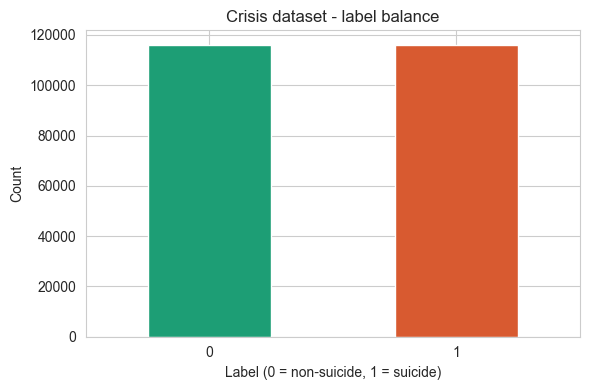

In [16]:
label_col_raw = "class"  # Kaggle dataset's label column name
text_col = "text"

print("Raw label counts:")
print(crisis_raw[label_col_raw].value_counts())
print("\nRaw label proportions:")
print(crisis_raw[label_col_raw].value_counts(normalize=True).round(3))

# Map to int: 1 = suicide, 0 = non-suicide
# Using a dict keeps the mapping explicit and fails loudly if a surprise
# label shows up (would become NaN which we can check for).
LABEL_MAP = {"suicide": 1, "non-suicide": 0}
crisis_raw["label"] = crisis_raw[label_col_raw].map(LABEL_MAP)

n_unmapped = crisis_raw["label"].isna().sum()
if n_unmapped > 0:
    unexpected = crisis_raw.loc[crisis_raw["label"].isna(), label_col_raw].unique()
    raise ValueError(f"Unexpected labels found: {unexpected}")
print(f"\nAll {len(crisis_raw):,} labels mapped cleanly to 0/1.")

label_col = "label"

fig, ax = plt.subplots(figsize=(6, 4))
crisis_raw[label_col].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#1D9E75", "#D85A30"]
)
ax.set_title("Crisis dataset - label balance")
ax.set_xlabel("Label (0 = non-suicide, 1 = suicide)")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "crisis_label_balance.png", dpi=120)
plt.show()

## Cell 14 - Random samples per class

Read a few from each class to sanity-check labels match the text.

In [17]:
for lbl in sorted(crisis_raw[label_col].dropna().unique()):
    class_name = {0: "non-suicide", 1: "suicide"}[int(lbl)]
    print(f"\n=== LABEL = {int(lbl)} ({class_name}) — sample of 3 ===")
    sample = crisis_raw[crisis_raw[label_col] == lbl].sample(3, random_state=RANDOM_STATE)
    for _, row in sample.iterrows():
        txt = str(row[text_col])
        print(f"- {txt[:300]}{'...' if len(txt) > 300 else ''}\n")


=== LABEL = 0 (non-suicide) — sample of 3 ===
- Used to keep it cool Used to be a fool 

All about the bounce in my step

Watch it on the news

Watchya gonna do

I could hit refresh and forget

Used to keep it cool

*epic trumpet noises*

- Well, haven't mat a girl like this in a while I asked her what Task Force 141 was and she replied with the voice actor of Captain Price. Thats a definite bruh girl

- My girlfriend just left me👍👍👍👍👍😁😁😁😁😁 I don't want to live anymore


=== LABEL = 1 (suicide) — sample of 3 ===
- Todays the day..I've got the thing I'll h*ng myself with. I'm just procrastinating.... I'm scared, and I just feel guilty. I couldnt sleep last night I kept thinking about who will find me just hanging there... it saddens me I have to leave this world like this

- Bad luckThis is my first post on Reddit ever. I've had many concussions resulting from different sports and also very bad luck. I can't really complain about the life I had: I had pretty much straight A's in buildi

## Cell 15 - Missing values and duplicates

In [18]:
print("Missing values:")
print(crisis_raw.isna().sum())
print(f"\nExact duplicate rows: {crisis_raw.duplicated().sum():,}")
print(f"Duplicate texts:      {crisis_raw.duplicated(subset=[text_col]).sum():,}")

Missing values:
text     0
class    0
label    0
dtype: int64

Exact duplicate rows: 0
Duplicate texts:      0


## Cell 16 - Text length distribution per class

Word count by label:
          count   mean    std  min   25%    50%    75%     max
label                                                         
0      116037.0   61.2  139.3  2.0  19.0   31.0   60.0  8220.0
1      116037.0  202.7  255.3  1.0  60.0  127.0  251.0  9684.0


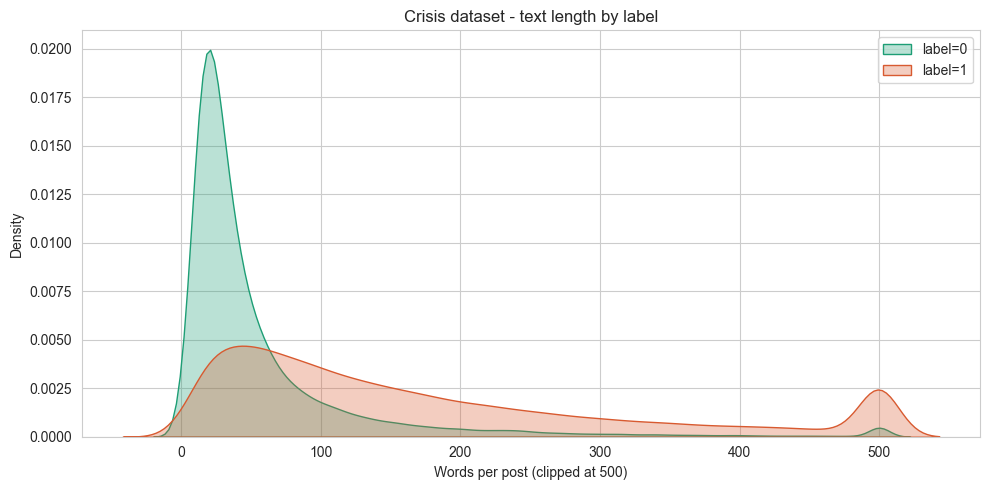

In [19]:
crisis_raw["n_words"] = crisis_raw[text_col].fillna("").astype(str).str.split().str.len()

print("Word count by label:")
print(crisis_raw.groupby(label_col)["n_words"].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
for lbl, colour in zip(sorted(crisis_raw[label_col].dropna().unique()), ["#1D9E75", "#D85A30"]):
    sns.kdeplot(
        crisis_raw.loc[crisis_raw[label_col] == lbl, "n_words"].clip(upper=500),
        label=f"label={int(lbl)}", ax=ax, color=colour, fill=True, alpha=0.3,
    )
ax.set_xlabel("Words per post (clipped at 500)")
ax.set_title("Crisis dataset - text length by label")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "crisis_length_by_label.png", dpi=120)
plt.show()

## Cell 17 - Apply cleaning to crisis data

DistilBERT truncates at 512 tokens (~400 words), so drop extreme
outliers but keep a wide range for the model to learn from.

In [20]:
crisis = crisis_raw.copy()
m0 = len(crisis)

crisis = crisis.dropna(subset=[text_col, label_col])
m1 = len(crisis)

crisis["text_clean"] = crisis[text_col].apply(clean_text)

crisis = crisis[crisis["text_clean"].str.len() > 10]
m2 = len(crisis)

crisis = crisis.drop_duplicates(subset=["text_clean"])
m3 = len(crisis)

crisis["n_words_clean"] = crisis["text_clean"].str.split().str.len()
crisis = crisis[(crisis["n_words_clean"] >= 3) & (crisis["n_words_clean"] <= 600)]
m4 = len(crisis)

# Ensure label is int after all filtering
crisis[label_col] = crisis[label_col].astype(int)

print("Rows after each step:")
print(f"  start           : {m0:,}")
print(f"  drop NA         : {m1:,}  (-{m0 - m1:,})")
print(f"  non-empty clean : {m2:,}  (-{m1 - m2:,})")
print(f"  drop duplicates : {m3:,}  (-{m2 - m3:,})")
print(f"  length filter   : {m4:,}  (-{m3 - m4:,})")
print(f"\nFinal retention: {m4 / m0 * 100:.1f}%")
print("\nClass balance after cleaning:")
print(crisis[label_col].value_counts(normalize=True).round(3))

Rows after each step:
  start           : 232,074
  drop NA         : 232,074  (-0)
  non-empty clean : 231,910  (-164)
  drop duplicates : 231,767  (-143)
  length filter   : 224,436  (-7,331)

Final retention: 96.7%

Class balance after cleaning:
label
0    0.513
1    0.487
Name: proportion, dtype: float64


## Cell 18 - Before/after sanity check

In [21]:
for _, row in crisis.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"label = {row[label_col]}")
    print(f"BEFORE: {str(row[text_col])[:300]}")
    print(f"AFTER : {row['text_clean'][:300]}")
    print("-" * 80)

label = 0
BEFORE: i'm tempted to stealing one of my brother's cigarretes nothing helps anymore so why not give it a shot
AFTER : i'm tempted to stealing one of my brother's cigarretes nothing helps anymore so why not give it a shot
--------------------------------------------------------------------------------
label = 0
BEFORE: I need some game recommendations I need some new switch games, price isn’t a problem. I would prefer something that’s more indie over anything else, but that’s not necessary. I’ve got BoTW, Smash and a few more games. I don’t have AC, but I’m not interested in it
AFTER : I need some game recommendations I need some new switch games, price isn t a problem. I would prefer something that s more indie over anything else, but that s not necessary. I ve got BoTW, Smash and a few more games. I don t have AC, but I m not interested in it
--------------------------------------------------------------------------------
label = 0
BEFORE: 16F, blonde 👱‍♀️ , skinny 🕴🏼,hot a

## Cell 19 - Save cleaned crisis data to interim

Columns saved: text_clean, label, n_words_clean
(Dropping the original string 'class' column — we use 'label' from now on.)

In [22]:
out_path = INTERIM_DATA_DIR / "crisis_clean.csv"
crisis[["text_clean", label_col, "n_words_clean"]].to_csv(out_path, index=False)
logger.success(f"Saved {len(crisis):,} cleaned rows to {out_path}")

2026-04-24 13:30:11.937 | SUCCESS  | __main__:<module>:3 - Saved 224,436 cleaned rows to D:\MS_DSI\AI\Assignment3\assignment3\data\interim\crisis_clean.csv


# SUMMARY

Outputs written to data/interim/:
- counsel_chat_clean.csv  (for chunking + FAISS indexing)
- crisis_clean.csv        (for train/val/test split + DistilBERT)

Figures in reports/figures/:
- counsel_topic_distribution.png
- counsel_length_distribution.png
- crisis_label_balance.png
- crisis_length_by_label.png

For the slide deck: record drop counts at each stage. Transparency
about preprocessing decisions earns marks on the ethics criterion.